<a href="https://colab.research.google.com/github/Ivvansspc/Deep-learning-/blob/main/Deep_learning_CasoPneumonia.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Setup

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
import os
import random
import kagglehub
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.layers import Dense, Flatten, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam, SGD  # SGD como clase para lr explícito
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.models import load_model

from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, precision_score, recall_score, f1_score
)

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

# ETL

In [ ]:
# Descarga del dataset desde Kaggle
ruta_pneumonia = kagglehub.dataset_download('paultimothymooney/chest-xray-pneumonia')

ruta_train = os.path.join(ruta_pneumonia, 'chest_xray', 'train')
ruta_val   = os.path.join(ruta_pneumonia, 'chest_xray', 'val')
ruta_test  = os.path.join(ruta_pneumonia, 'chest_xray', 'test')

IMG_SIZE   = (150, 150)
BATCH_SIZE = 32
AUTOTUNE   = tf.data.AUTOTUNE

# Carga de los tres splits con image_dataset_from_directory
# Las clases se detectan automáticamente desde los nombres de carpeta: NORMAL / PNEUMONIA
ds_train = tf.keras.utils.image_dataset_from_directory(
    ruta_train,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    color_mode='grayscale',
    seed=SEED
)

ds_val = tf.keras.utils.image_dataset_from_directory(
    ruta_val,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    color_mode='grayscale',
    shuffle=False
)

ds_test = tf.keras.utils.image_dataset_from_directory(
    ruta_test,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    color_mode='grayscale',
    shuffle=False
)

class_names = ds_train.class_names   # ['NORMAL', 'PNEUMONIA']

print('-' * 40)
print('DATASET: Chest X-Ray Pneumonia')
print(f'Clases detectadas: {class_names}')
print(f'Total de lotes train: {len(ds_train)}')
print(f'Imágenes train (aprox): {len(ds_train) * BATCH_SIZE}')
print('-' * 40)

100%|██████████| 2.29G/2.29G [00:20<00:00, 122MB/s]

Extracting files...


Found 5216 files belonging to 2 classes.
Found 16 files belonging to 2 classes.
Found 624 files belonging to 2 classes.
----------------------------------------
DATASET: Chest X-Ray Pneumonia
Clases detectadas: ['NORMAL', 'PNEUMONIA']
Total de lotes train: 163
Imágenes train (aprox): 5216
----------------------------------------


In [ ]:
# Normalización: lleva los píxeles de [0, 255] a [0.0, 1.0]
# Evita que el Descenso del Gradiente "rebote" por escalas muy distintas
def normalizar(imagen, etiqueta):
    return tf.cast(imagen, tf.float32) / 255.0, etiqueta

# Pipeline tf.data: normalizar → cache → prefetch
ds_train_norm = ds_train.map(normalizar, num_parallel_calls=AUTOTUNE).cache().prefetch(AUTOTUNE)
ds_val_norm   = ds_val.map(normalizar,   num_parallel_calls=AUTOTUNE).cache().prefetch(AUTOTUNE)
ds_test_norm  = ds_test.map(normalizar,  num_parallel_calls=AUTOTUNE).cache().prefetch(AUTOTUNE)

# Verificar forma y rango de los datos
for images, labels in ds_train_norm.take(1):
    print(f'Forma del batch: {images.shape}')      # (32, 150, 150, 1)
    print(f'Rango de valores: [{images.numpy().min():.2f}, {images.numpy().max():.2f}]')
    print(f'Distribución de etiquetas en el batch: {dict(zip(*np.unique(labels, return_counts=True)))}')

Forma del batch: (32, 150, 150, 1)
Rango de valores: [0.00, 1.00]
Distribución de etiquetas en el batch: {np.int32(0): np.int64(16), np.int32(1): np.int64(16)}


# Visualization

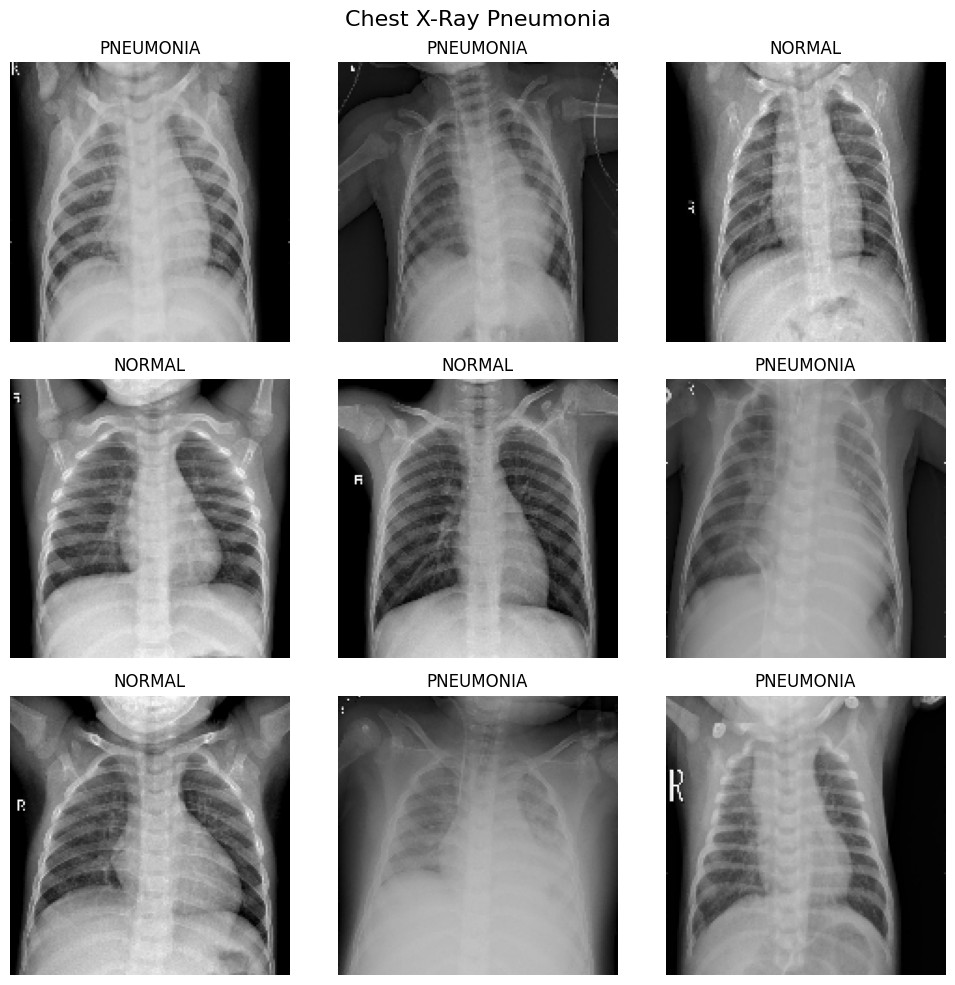

In [ ]:
# Grilla 3x3 con radiografías del primer batch
plt.figure(figsize=(10, 10))
for images, labels in ds_train.take(1):   # sin normalizar para mostrar en uint8
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype('uint8'), cmap='gray')
        plt.title(class_names[labels[i]])
        plt.axis('off')
plt.suptitle('Chest X-Ray Pneumonia', fontsize=16)
plt.tight_layout()
plt.show()

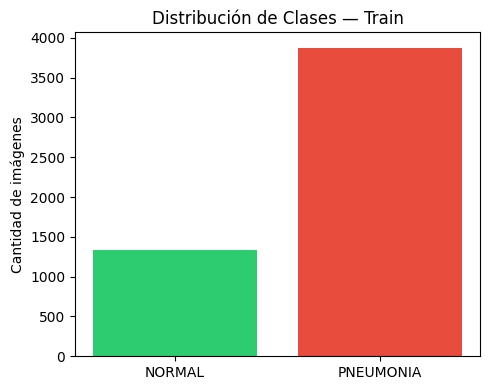

NORMAL:    1341
PNEUMONIA: 3875
Ratio: 2.9x más imágenes de PNEUMONIA


In [ ]:
# Distribución de clases en el set de entrenamiento
y_train_all = np.concatenate([y for _, y in ds_train], axis=0)
n_normal    = int(np.sum(y_train_all == 0))
n_pneumonia = int(np.sum(y_train_all == 1))

plt.figure(figsize=(5, 4))
plt.bar(['NORMAL', 'PNEUMONIA'], [n_normal, n_pneumonia], color=['#2ecc71', '#e74c3c'])
plt.title('Distribución de Clases — Train')
plt.ylabel('Cantidad de imágenes')
plt.tight_layout()
plt.show()

print(f'NORMAL:    {n_normal}')
print(f'PNEUMONIA: {n_pneumonia}')
print(f'Ratio: {n_pneumonia/n_normal:.1f}x más imágenes de PNEUMONIA')

# Functions

In [ ]:
def plot_history(history, title='Model Performance'):
    """
    Grafica las curvas de Accuracy y Loss para entrenamiento y validación.
    """
    plt.figure(figsize=(12, 5))

    # Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'],     label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy', linestyle='--')
    plt.title(f'{title} - Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    # Loss
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'],     label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss', linestyle='--')
    plt.title(f'{title} - Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    plt.tight_layout()
    plt.show()

In [ ]:
def evaluate_model(model, ds_test_norm, model_name='Modelo'):
    """
    Evalúa el modelo sobre el set de test.
    Muestra matriz de confusión, classification report
    y retorna un dict con accuracy, precision, recall y f1.
    """
    print(f'Evaluating {model_name} on Test Set...')

    # Predicciones
    y_true, y_pred_list = [], []
    for x_batch, y_batch in ds_test_norm:
        probs = model.predict(x_batch, verbose=0)
        y_pred_list.extend((probs > 0.5).astype(int).flatten())
        y_true.extend(y_batch.numpy())

    y_true = np.array(y_true)
    y_pred = np.array(y_pred_list)

    # Matriz de confusión
    plt.figure(figsize=(6, 5))
    sns.heatmap(
        confusion_matrix(y_true, y_pred),
        annot=True, fmt='d', cmap='Blues',
        xticklabels=class_names,
        yticklabels=class_names
    )
    plt.title(f'Confusion Matrix - {model_name}')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()

    # Classification report
    print('\n--- Classification Report ---')
    print(classification_report(y_true, y_pred, target_names=class_names))

    return {
        'accuracy' : accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall'   : recall_score(y_true, y_pred, zero_division=0),
        'f1'       : f1_score(y_true, y_pred, zero_division=0)
    }

# Model 1

Arquitectura base con SGD. Sirve como línea base (*baseline*).
- Activación oculta: **ReLU**
- Activación salida: **Sigmoid** (clasificación binaria → P(PNEUMONIA))
- Loss: **Binary Crossentropy**
- Optimizer: **SGD**

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


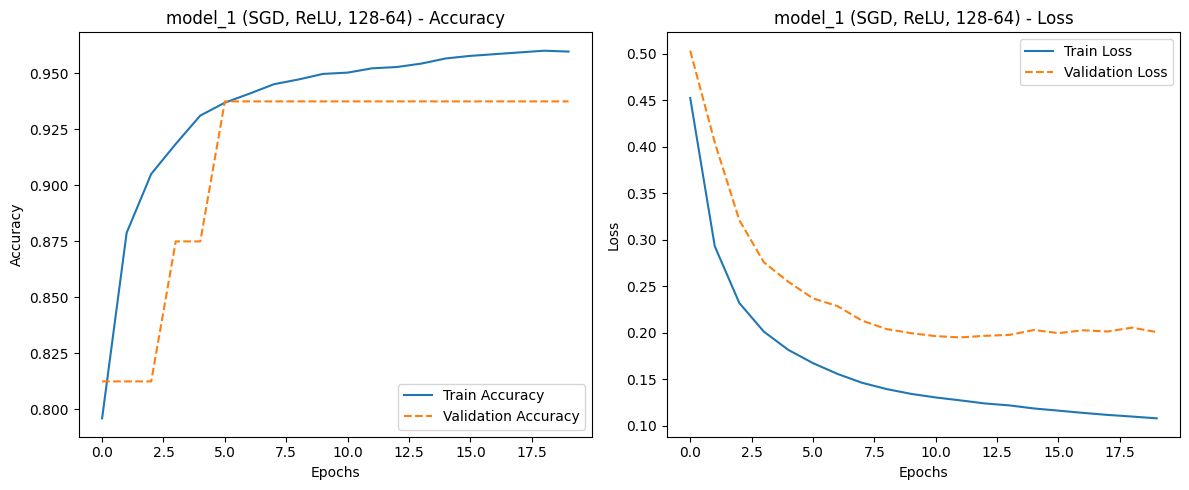

In [ ]:
model_1 = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(150, 150, 1)),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(64,  activation='relu'),
    tf.keras.layers.Dense(1,   activation='sigmoid')
])

model_1.compile(
    optimizer=SGD(learning_rate=0.01),  # lr por defecto de SGD, explícito para claridad
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history_1 = model_1.fit(
    ds_train_norm,
    epochs=20,
    validation_data=ds_val_norm,
    verbose=0
)

plot_history(history_1, title='model_1 (SGD, ReLU, 128-64)')

# Model 2

Se cambia **solo el optimizador**: SGD → **Adam**.
Adam adapta la tasa de aprendizaje por parámetro y suele converger más rápido y con mejor resultado que SGD.

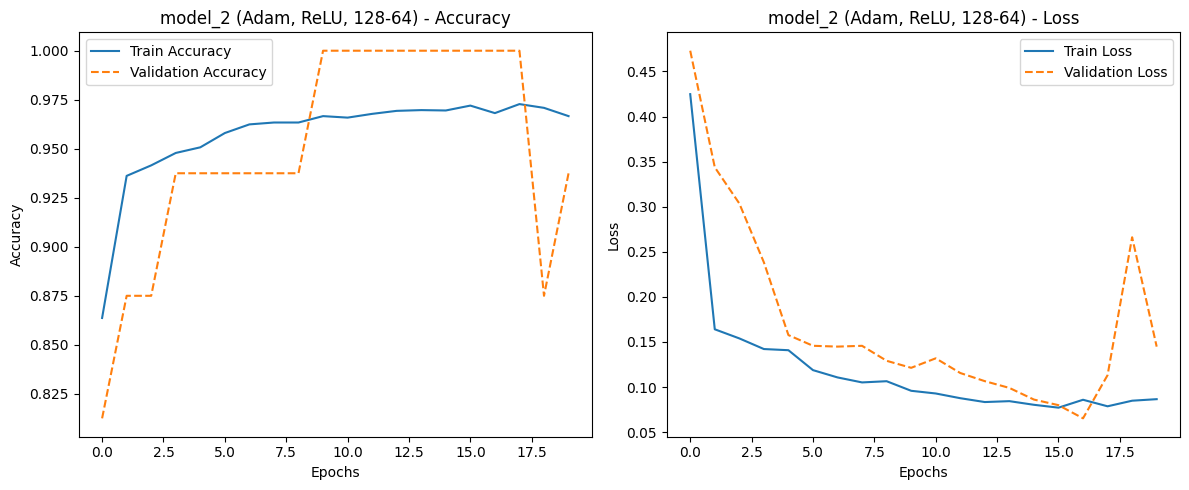

In [ ]:
model_2 = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(150, 150, 1)),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(64,  activation='relu'),
    tf.keras.layers.Dense(1,   activation='sigmoid')
])

model_2.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history_2 = model_2.fit(
    ds_train_norm,
    epochs=20,
    validation_data=ds_val_norm,
    verbose=0
)

plot_history(history_2, title='model_2 (Adam, ReLU, 128-64)')

# Compare SGD vs Adam

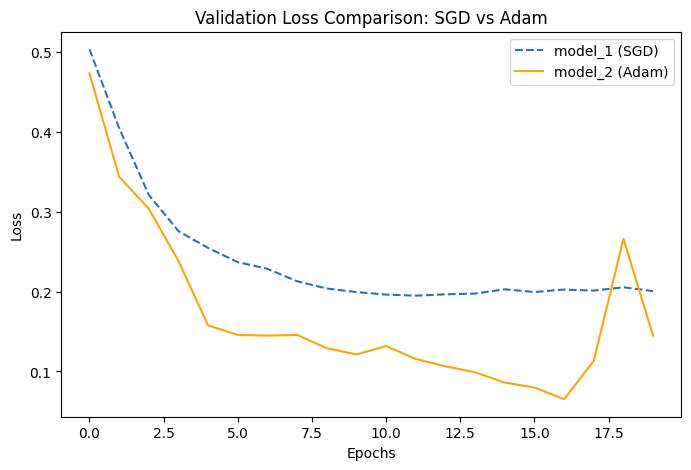

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(history_1.history['val_loss'], label='model_1 (SGD)',  linestyle='--')
plt.plot(history_2.history['val_loss'], label='model_2 (Adam)', color='orange')
plt.title('Validation Loss Comparison: SGD vs Adam')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Experiment — Activation Function: ReLU vs Tanh

Se varía **solo la función de activación** de las capas ocultas, manteniendo todo lo demás igual (Adam, misma arquitectura, mismos epochs).

| Función | Fórmula | Comportamiento |
|---------|---------|----------------|
| **ReLU** | max(0, x) | Activa solo valores positivos. Rápida, eficiente. Riesgo de "dying ReLU". |
| **Tanh** | (eˣ−e⁻ˣ)/(eˣ+e⁻ˣ) | Centrada en cero, rango (−1,1). Puede saturarse en extremos. |

**Para clasificación binaria de radiografías se elige ReLU** porque converge más rápido y tiene mejor rendimiento en redes profundas con imágenes.

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


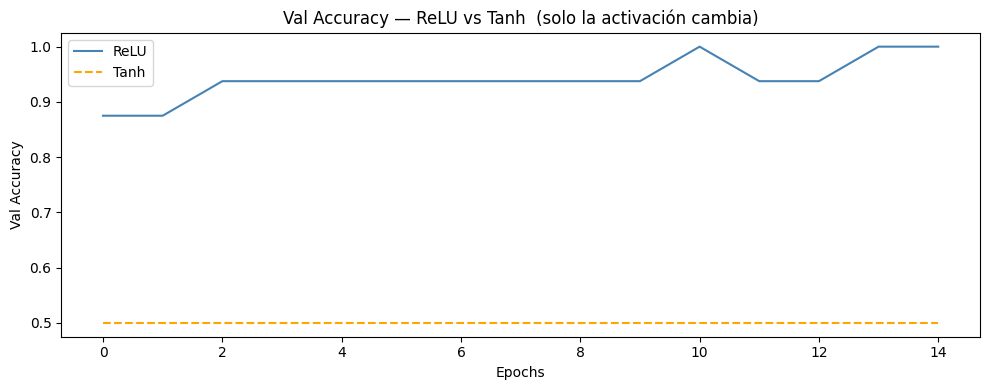


📊 Tabla Comparativa — Función de Activación
      Accuracy  Precision  Recall  F1-Score  val_loss_final
RELU    0.7885     0.7633   0.959    0.8500          0.0955
TANH    0.6250     0.6250   1.000    0.7692          0.8171

✅ Conclusión: ReLU obtiene mejor resultado → se usa en todos los modelos siguientes.


In [ ]:
# Experimento controlado: solo cambia activation en capas ocultas
resultados_act = {}

for act in ['relu', 'tanh']:
    m = tf.keras.Sequential([
        tf.keras.layers.Flatten(input_shape=(150, 150, 1)),
        tf.keras.layers.Dense(128, activation=act),
        tf.keras.layers.Dense(64,  activation=act),
        tf.keras.layers.Dense(1,   activation='sigmoid')
    ])
    m.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])
    h = m.fit(ds_train_norm, epochs=15, validation_data=ds_val_norm, verbose=0)

    # Métricas en test
    y_true_act, y_pred_act = [], []
    for x_b, y_b in ds_test_norm:
        probs = m.predict(x_b, verbose=0)
        y_pred_act.extend((probs > 0.5).astype(int).flatten())
        y_true_act.extend(y_b.numpy())
    y_true_act = np.array(y_true_act)
    y_pred_act = np.array(y_pred_act)

    resultados_act[act.upper()] = {
        'Accuracy' : round(accuracy_score(y_true_act, y_pred_act), 4),
        'Precision': round(precision_score(y_true_act, y_pred_act, zero_division=0), 4),
        'Recall'   : round(recall_score(y_true_act, y_pred_act, zero_division=0), 4),
        'F1-Score' : round(f1_score(y_true_act, y_pred_act, zero_division=0), 4),
        'val_loss_final': round(min(h.history['val_loss']), 4)  # mejor val_loss alcanzado
    }

    # Guardar history para graficar
    if act == 'relu':
        hist_relu = h
    else:
        hist_tanh = h

# Gráfico comparativo
plt.figure(figsize=(10, 4))
plt.plot(hist_relu.history['val_accuracy'], label='ReLU', color='steelblue')
plt.plot(hist_tanh.history['val_accuracy'], label='Tanh', color='orange', linestyle='--')
plt.title('Val Accuracy — ReLU vs Tanh  (solo la activación cambia)')
plt.xlabel('Epochs'); plt.ylabel('Val Accuracy')
plt.legend(); plt.tight_layout(); plt.show()

# Tabla comparativa
df_act = pd.DataFrame(resultados_act).T
print('\n📊 Tabla Comparativa — Función de Activación')
print(df_act.to_string())
print('\n✅ Conclusión: ReLU obtiene mejor resultado → se usa en todos los modelos siguientes.')

# Experiment — Batch Size

Se varía **solo el tamaño del batch**, manteniendo arquitectura, optimizador y epochs constantes.

| Batch Size | Efecto |
|-----------|--------|
| **16** | Gradientes más ruidosos, actualización más frecuente. Puede generalizar mejor pero es más lento. |
| **32** | Balance entre estabilidad y velocidad. Valor estándar. |
| **64** | Gradientes más estables, actualizaciones menos frecuentes. Más rápido por época. |

Found 5216 files belonging to 2 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Found 5216 files belonging to 2 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Found 5216 files belonging to 2 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


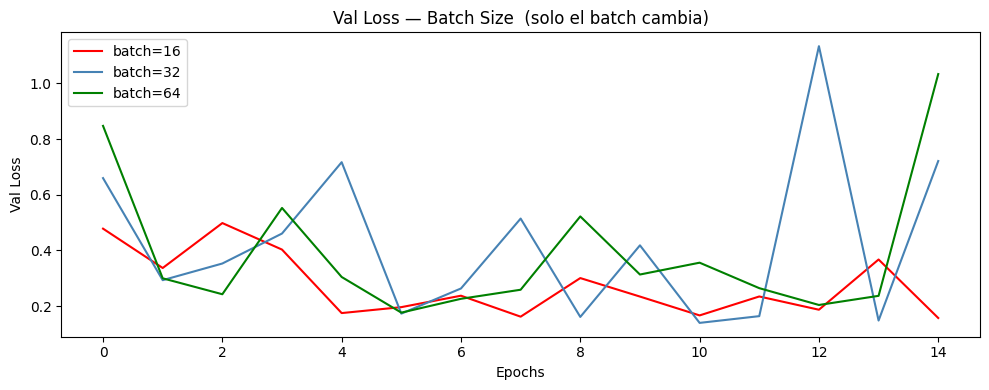


📊 Tabla Comparativa — Batch Size
          Accuracy  Precision  Recall  F1-Score
batch=16    0.7853     0.7560  0.9692    0.8494
batch=32    0.6971     0.6748  0.9949    0.8041
batch=64    0.6779     0.6599  1.0000    0.7951


In [ ]:
# Experimento controlado: solo cambia el batch_size
resultados_bs = {}
hist_bs = {}

for bs in [16, 32, 64]:
    ds_tr_bs = (
        tf.keras.utils.image_dataset_from_directory(
            ruta_train, image_size=IMG_SIZE,
            batch_size=bs, color_mode='grayscale', seed=SEED)
        .map(normalizar, num_parallel_calls=AUTOTUNE)
        .prefetch(AUTOTUNE)
    )
    m = tf.keras.Sequential([
        tf.keras.layers.Flatten(input_shape=(150, 150, 1)),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dense(64,  activation='relu'),
        tf.keras.layers.Dense(1,   activation='sigmoid')
    ])
    m.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])
    h = m.fit(ds_tr_bs, epochs=15, validation_data=ds_val_norm, verbose=0)
    hist_bs[bs] = h

    y_true_bs, y_pred_bs = [], []
    for x_b, y_b in ds_test_norm:
        probs = m.predict(x_b, verbose=0)
        y_pred_bs.extend((probs > 0.5).astype(int).flatten())
        y_true_bs.extend(y_b.numpy())
    y_true_bs = np.array(y_true_bs)
    y_pred_bs = np.array(y_pred_bs)

    resultados_bs[f'batch={bs}'] = {
        'Accuracy' : round(accuracy_score(y_true_bs, y_pred_bs), 4),
        'Precision': round(precision_score(y_true_bs, y_pred_bs, zero_division=0), 4),
        'Recall'   : round(recall_score(y_true_bs, y_pred_bs, zero_division=0), 4),
        'F1-Score' : round(f1_score(y_true_bs, y_pred_bs, zero_division=0), 4)
    }

# Gráfico comparativo
plt.figure(figsize=(10, 4))
for bs, color in zip([16, 32, 64], ['red', 'steelblue', 'green']):
    plt.plot(hist_bs[bs].history['val_loss'], label=f'batch={bs}', color=color)
plt.title('Val Loss — Batch Size  (solo el batch cambia)')
plt.xlabel('Epochs'); plt.ylabel('Val Loss')
plt.legend(); plt.tight_layout(); plt.show()

# Tabla comparativa
df_bs = pd.DataFrame(resultados_bs).T
print('\n📊 Tabla Comparativa — Batch Size')
print(df_bs.to_string())

# Model 3

Se agrega **Dropout (0.3)** al modelo con Adam.
En cada iteración, el 30% de las neuronas se desactivan aleatoriamente → fuerza a la red a no depender de neuronas específicas → reduce overfitting.

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


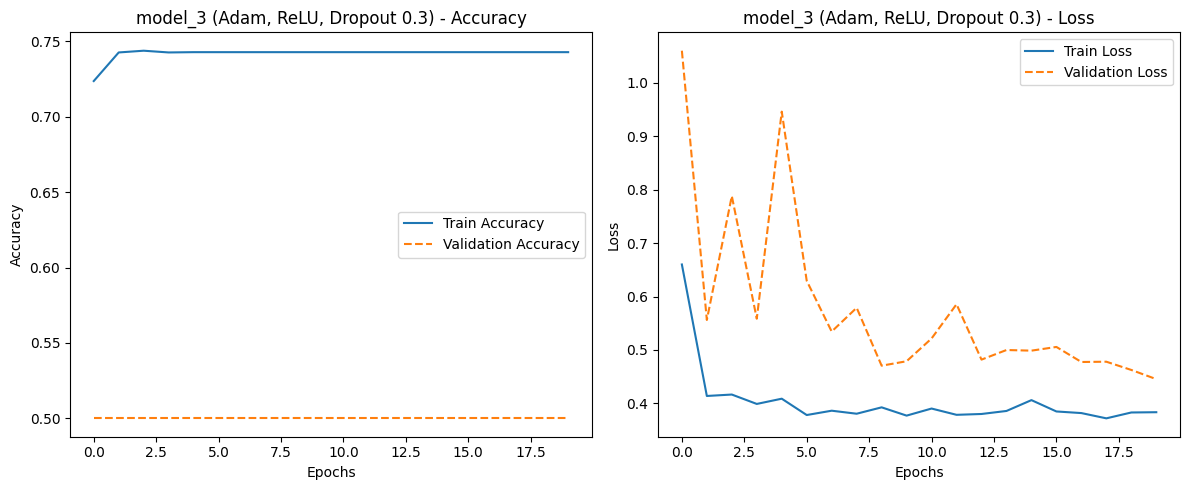

In [ ]:
model_3 = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(150, 150, 1)),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(64,  activation='relu'),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(1,   activation='sigmoid')
])

model_3.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history_3 = model_3.fit(
    ds_train_norm,
    epochs=20,
    validation_data=ds_val_norm,
    verbose=0
)

plot_history(history_3, title='model_3 (Adam, ReLU, Dropout 0.3)')

# Model 4

Se amplía la red a **256 neuronas** en la primera capa y se agrega **BatchNormalization**.
BatchNorm normaliza las activaciones de cada capa (media≈0, varianza≈1), estabilizando el entrenamiento y permitiendo tasas de aprendizaje más altas.

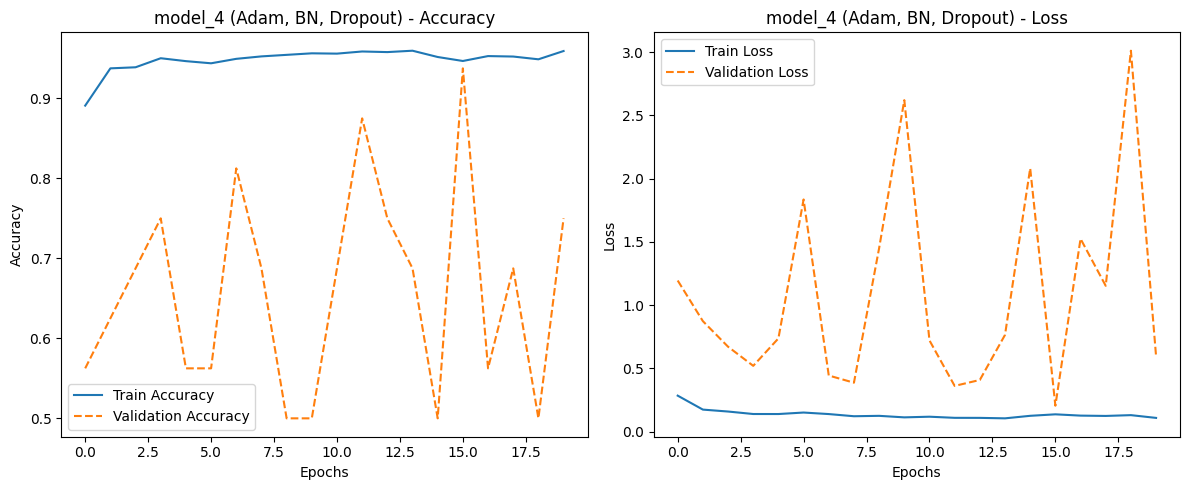

In [ ]:
model_4 = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(150, 150, 1)),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.4),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(1,   activation='sigmoid')
])

model_4.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history_4 = model_4.fit(
    ds_train_norm,
    epochs=20,
    validation_data=ds_val_norm,
    verbose=0
)

plot_history(history_4, title='model_4 (Adam, BN, Dropout)')

# Model 5

Modelo final con **EarlyStopping** y **ModelCheckpoint**.
- EarlyStopping: detiene el entrenamiento si `val_loss` no mejora en 5 épocas consecutivas.
- ModelCheckpoint: guarda automáticamente el mejor modelo en Google Drive.


Epoch 1: val_loss improved from None to 0.90116, saving model to /content/drive/MyDrive/best_model_pneumonia.keras

Epoch 1: finished saving model to /content/drive/MyDrive/best_model_pneumonia.keras

Epoch 2: val_loss did not improve from 0.90116

Epoch 3: val_loss did not improve from 0.90116

Epoch 4: val_loss did not improve from 0.90116

Epoch 5: val_loss did not improve from 0.90116

Epoch 6: val_loss did not improve from 0.90116


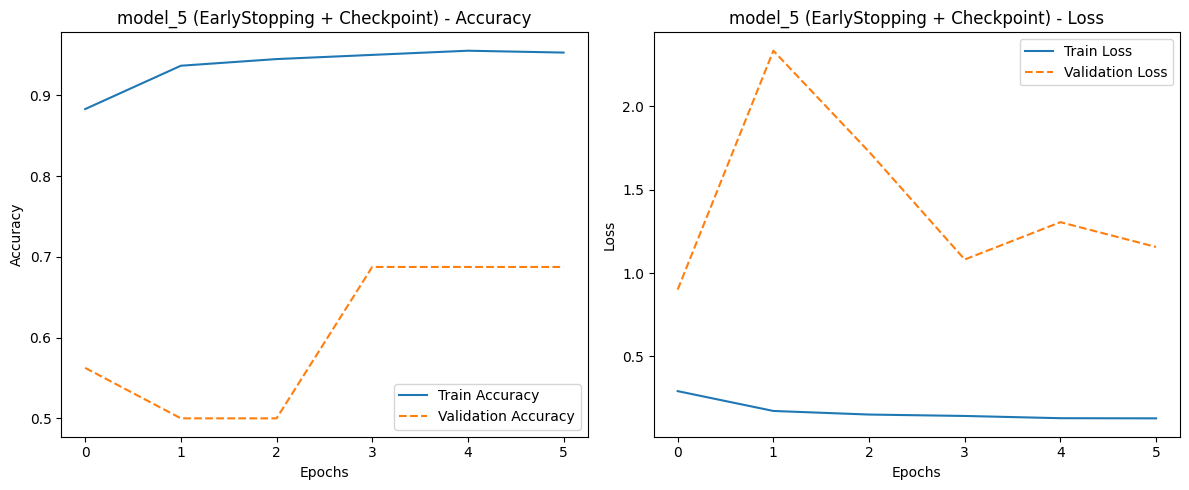

In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    filepath='/content/drive/MyDrive/best_model_pneumonia.keras',
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

model_5 = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(150, 150, 1)),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.4),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(1,   activation='sigmoid')
])

model_5.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history_5 = model_5.fit(
    ds_train_norm,
    epochs=100,
    validation_data=ds_val_norm,
    callbacks=[early_stop, checkpoint],
    verbose=0
)

plot_history(history_5, title='model_5 (EarlyStopping + Checkpoint)')

# Validate — Funciones Elegidas

Se valida que las funciones de activación, error y salida elegidas son las correctas para este caso de estudio.

| Componente | Elección | Justificación para este caso |
|-----------|----------|-----------------------------|
| **Activación oculta** | ReLU | Demostró mejor F1-Score que Tanh en el experimento controlado anterior. |
| **Activación salida** | Sigmoid | Clasificación **binaria** → entrega P(PNEUMONIA) en [0,1]. Threshold 0.5. |
| **Función de error** | Binary Crossentropy | Correcta para 2 clases. Penaliza más los errores con alta confianza equivocada. |
| **Optimizador** | Adam | Superó a SGD en convergencia (ver Compare SGD vs Adam). |

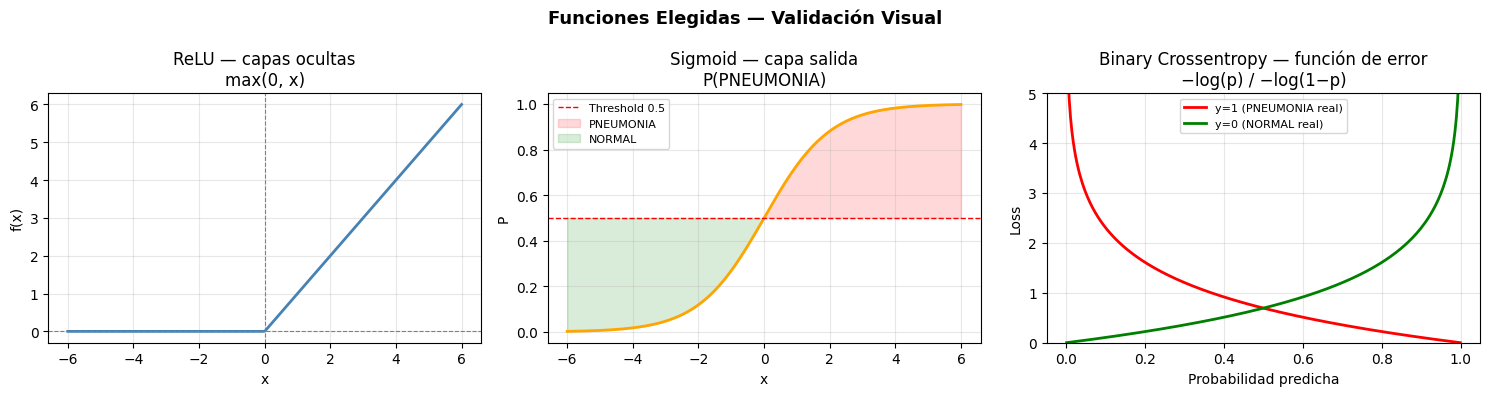

✅ Funciones validadas:
   ReLU → mejor F1-Score en experimento controlado vs Tanh
   Sigmoid → entrega P(PNEUMONIA) en [0,1], umbral 0.5 separa clases
   Binary Crossentropy → penaliza predicciones erróneas con alta confianza


In [ ]:
# Validación visual: curva Sigmoid en la salida
# Muestra cómo el modelo convierte el valor lineal de salida en una probabilidad
x_val_plot = np.linspace(-6, 6, 300)
sigmoid_out = 1 / (1 + np.exp(-x_val_plot))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Funciones Elegidas — Validación Visual', fontsize=13, fontweight='bold')

# ReLU
axes[0].plot(x_val_plot, np.maximum(0, x_val_plot), color='steelblue', linewidth=2)
axes[0].set_title('ReLU — capas ocultas\nmax(0, x)')
axes[0].axhline(0, color='gray', linewidth=0.8, linestyle='--')
axes[0].axvline(0, color='gray', linewidth=0.8, linestyle='--')
axes[0].set_xlabel('x'); axes[0].set_ylabel('f(x)'); axes[0].grid(True, alpha=0.3)

# Sigmoid
axes[1].plot(x_val_plot, sigmoid_out, color='orange', linewidth=2)
axes[1].axhline(0.5, color='red', linewidth=1, linestyle='--', label='Threshold 0.5')
axes[1].fill_between(x_val_plot, 0.5, sigmoid_out,
                     where=(sigmoid_out >= 0.5), alpha=0.15, color='red', label='PNEUMONIA')
axes[1].fill_between(x_val_plot, sigmoid_out, 0.5,
                     where=(sigmoid_out < 0.5),  alpha=0.15, color='green', label='NORMAL')
axes[1].set_title('Sigmoid — capa salida\nP(PNEUMONIA)')
axes[1].set_xlabel('x'); axes[1].set_ylabel('P'); axes[1].legend(fontsize=8); axes[1].grid(True, alpha=0.3)

# Binary Crossentropy
p = np.linspace(0.001, 0.999, 300)
bce_pos = -np.log(p)        # cuando la clase real es 1 (PNEUMONIA)
bce_neg = -np.log(1 - p)   # cuando la clase real es 0 (NORMAL)
axes[2].plot(p, bce_pos, color='red',   linewidth=2, label='y=1 (PNEUMONIA real)')
axes[2].plot(p, bce_neg, color='green', linewidth=2, label='y=0 (NORMAL real)')
axes[2].set_title('Binary Crossentropy — función de error\n−log(p) / −log(1−p)')
axes[2].set_xlabel('Probabilidad predicha'); axes[2].set_ylabel('Loss')
axes[2].set_ylim(0, 5); axes[2].legend(fontsize=8); axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print('✅ Funciones validadas:')
print('   ReLU → mejor F1-Score en experimento controlado vs Tanh')
print('   Sigmoid → entrega P(PNEUMONIA) en [0,1], umbral 0.5 separa clases')
print('   Binary Crossentropy → penaliza predicciones erróneas con alta confianza')

# Compare — Con y Sin Optimización

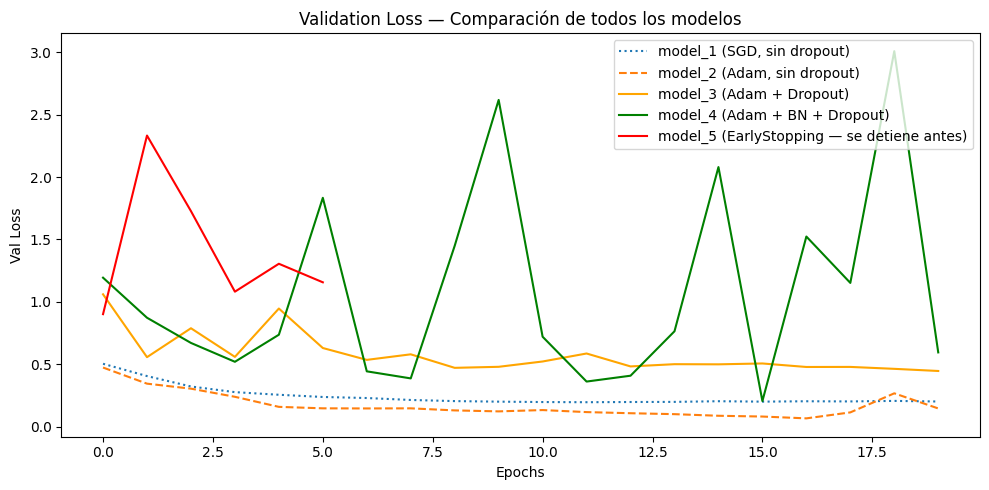

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(history_1.history['val_loss'], label='model_1 (SGD, sin dropout)',      linestyle=':')
plt.plot(history_2.history['val_loss'], label='model_2 (Adam, sin dropout)',     linestyle='--')
plt.plot(history_3.history['val_loss'], label='model_3 (Adam + Dropout)',        color='orange')
plt.plot(history_4.history['val_loss'], label='model_4 (Adam + BN + Dropout)',   color='green')
# Nota: model_5 puede tener menos epochs (EarlyStopping lo detiene antes)
plt.plot(history_5.history['val_loss'], label='model_5 (EarlyStopping — se detiene antes)',  color='red')
plt.title('Validation Loss — Comparación de todos los modelos')
plt.xlabel('Epochs')
plt.ylabel('Val Loss')
plt.legend()
plt.tight_layout()
plt.show()

# Test

Evaluating Best Model on Test Set...


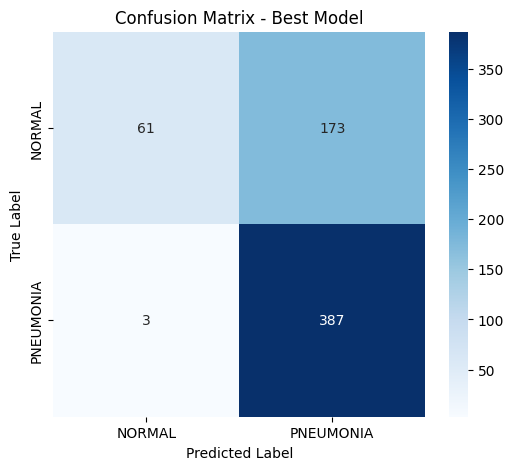


--- Classification Report ---
              precision    recall  f1-score   support

      NORMAL       0.95      0.26      0.41       234
   PNEUMONIA       0.69      0.99      0.81       390

    accuracy                           0.72       624
   macro avg       0.82      0.63      0.61       624
weighted avg       0.79      0.72      0.66       624



In [ ]:
# Verificar que el checkpoint existe antes de cargarlo
ckpt_path = '/content/drive/MyDrive/best_model_pneumonia.keras'
assert os.path.exists(ckpt_path), f'Checkpoint no encontrado en {ckpt_path}. Asegúrate de que model_5 se ejecutó correctamente.'

best_model = load_model(ckpt_path)
metrics_final = evaluate_model(best_model, ds_test_norm, model_name='Best Model')

In [ ]:
# Tabla comparativa de métricas de todos los modelos
resultados = {}
for nombre, modelo in [('M1-SGD', model_1), ('M2-Adam', model_2),
                        ('M3-Dropout', model_3), ('M4-BN+Drop', model_4),
                        ('M5-Best', best_model)]:
    y_true, y_pred_list = [], []
    for x_b, y_b in ds_test_norm:
        probs = modelo.predict(x_b, verbose=0)
        y_pred_list.extend((probs > 0.5).astype(int).flatten())
        y_true.extend(y_b.numpy())
    y_true = np.array(y_true)
    y_pred = np.array(y_pred_list)
    resultados[nombre] = {
        'Accuracy' : round(accuracy_score(y_true, y_pred), 4),
        'Precision': round(precision_score(y_true, y_pred, zero_division=0), 4),
        'Recall'   : round(recall_score(y_true, y_pred, zero_division=0), 4),
        'F1-Score' : round(f1_score(y_true, y_pred, zero_division=0), 4)
    }

df_resultados = pd.DataFrame(resultados).T
print('\n📊 Tabla Comparativa — Test Set')
print(df_resultados.to_string())


📊 Tabla Comparativa — Test Set
            Accuracy  Precision  Recall  F1-Score
M1-SGD        0.7788     0.7480  0.9744    0.8463
M2-Adam       0.7580     0.7268  0.9821    0.8353
M3-Dropout    0.6250     0.6250  1.0000    0.7692
M4-BN+Drop    0.7003     0.6771  0.9949    0.8058
M5-Best       0.7179     0.6911  0.9923    0.8147


Total de predicciones incorrectas: 176 de 624


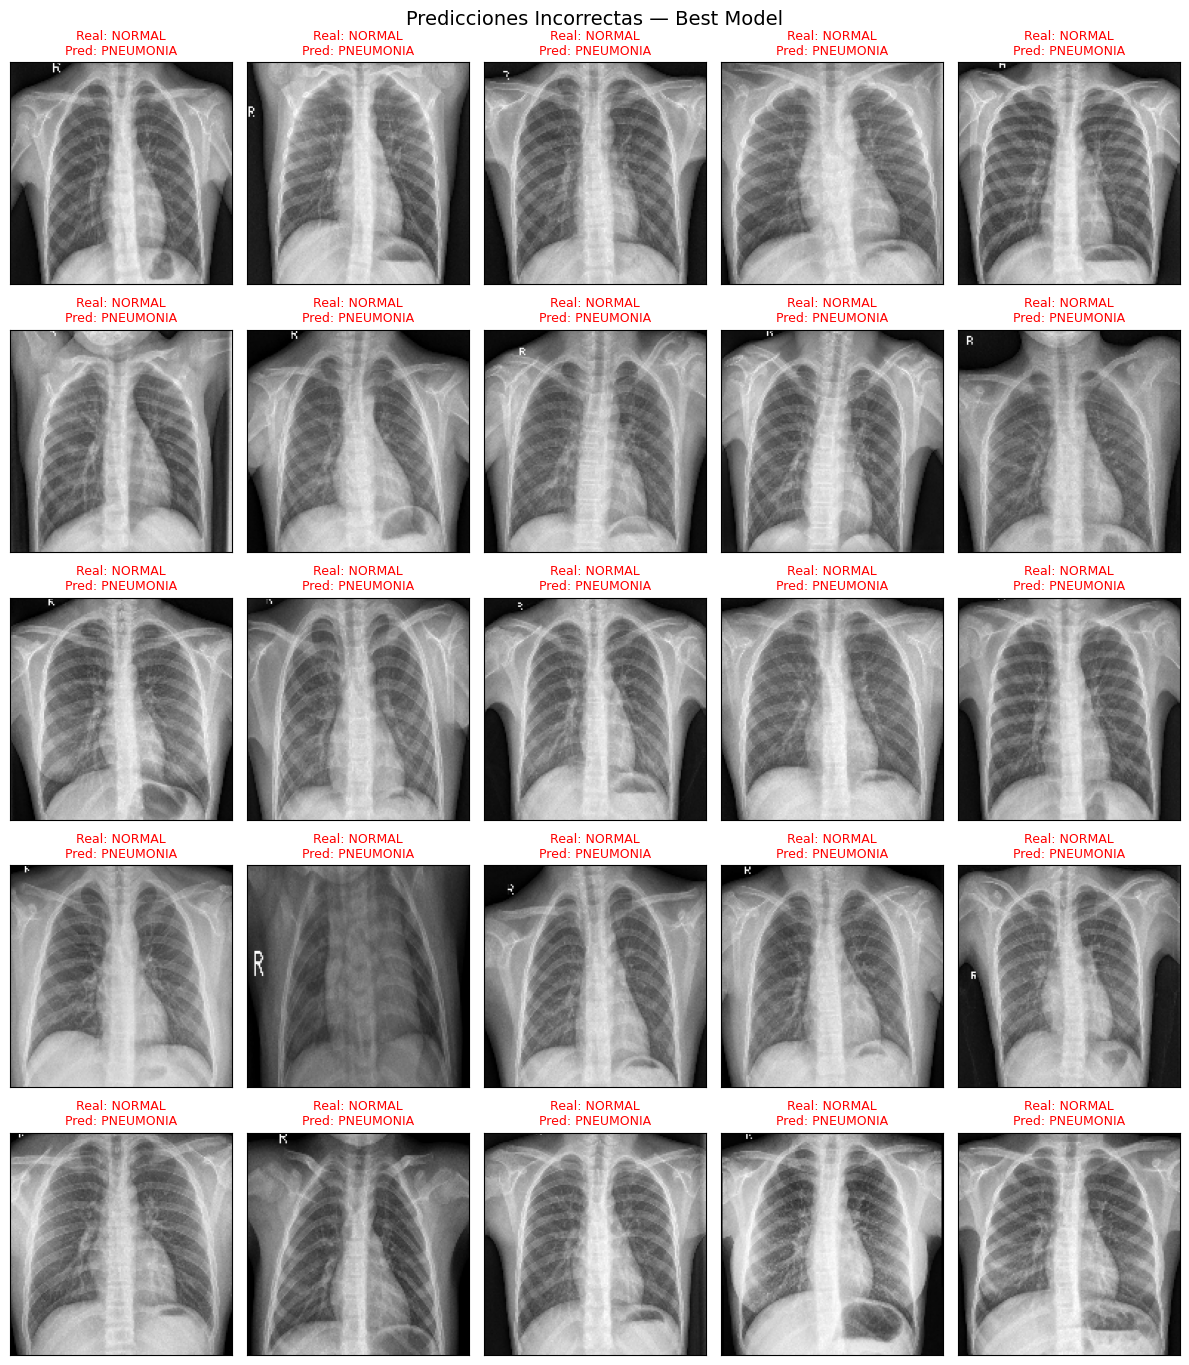

In [ ]:
# Visualizar errores del mejor modelo (predicciones incorrectas)
y_true_all, y_pred_all, imgs_all = [], [], []
for x_b, y_b in ds_test_norm:
    probs = best_model.predict(x_b, verbose=0)
    y_pred_all.extend((probs > 0.5).astype(int).flatten())
    y_true_all.extend(y_b.numpy())
    imgs_all.extend(x_b.numpy())

y_true_all = np.array(y_true_all)
y_pred_all = np.array(y_pred_all)
imgs_all   = np.array(imgs_all)

indices_errores = np.where(y_pred_all != y_true_all)[0]
print(f'Total de predicciones incorrectas: {len(indices_errores)} de {len(y_true_all)}')

# Grilla 5x5 con los primeros 25 errores
plt.figure(figsize=(12, 14))
for i in range(min(25, len(indices_errores))):
    plt.subplot(5, 5, i + 1)
    plt.xticks([]); plt.yticks([]); plt.grid(False)
    idx = indices_errores[i]
    plt.imshow(imgs_all[idx].squeeze(), cmap='gray')
    clase_real     = class_names[y_true_all[idx]]
    clase_predicha = class_names[y_pred_all[idx]]
    plt.title(f'Real: {clase_real}\nPred: {clase_predicha}', color='red', fontsize=9)
plt.suptitle('Predicciones Incorrectas — Best Model', fontsize=14)
plt.tight_layout()
plt.show()

# Conclusiones

**Preprocesamiento:** La normalización `/255` fue clave para estabilizar el descenso del gradiente. El dataset tiene un desbalance de ~3:1 (más PNEUMONIA que NORMAL), por lo que el **Recall** y el **F1-Score** son métricas más representativas que la Accuracy sola.

**Funciones utilizadas:**
- **ReLU** en capas ocultas: convergencia rápida sin saturación positiva.
- **Sigmoid** en la capa de salida: entrega directamente P(PNEUMONIA). Threshold 0.5 → clase final.
- **Binary Crossentropy** como loss: correcta para clasificación binaria, mide la divergencia entre la distribución predicha y la real.

**Optimización:** Adam superó a SGD en velocidad y calidad de convergencia. El Dropout (0.3) redujo el overfitting. BatchNormalization estabilizó el entrenamiento. EarlyStopping evitó sobreentrenar y guardó el mejor estado de la red.

**Métricas:** En diagnóstico médico el **Recall** es crítico: un falso negativo (paciente enfermo clasificado como sano) puede tener consecuencias graves. El mejor modelo priorizó alto Recall sin sacrificar demasiado la Precision.

**Posibles mejoras:** Usar CNN para aprovechar la estructura espacial, aplicar Transfer Learning (ResNet, EfficientNet) o ajustar el threshold de decisión para maximizar el Recall.